In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Helper to load an Arrow file
# -------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# -------------------------
# Detect division events by large mass drops
# -------------------------
def detect_divisions(df, thresh=0.55):
    # Total ribosome-linked mass proxy:
    total_ribs = df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"]
    ratio = total_ribs.iloc[1:].values / total_ribs.iloc[:-1].values
    
    # Divisions appear as drops ~0.5
    div_idx = np.where(ratio < thresh)[0] + 1  # shift for alignment
    return div_idx

# -------------------------
# Extract cell cycles as segments
# -------------------------
def extract_cycles(df, div_idx):
    cycles = []
    prev = 0
    for d in div_idx:
        cycles.append(df.iloc[prev:d].copy())
        prev = d
    # Add last cycle (may be incomplete)
    if prev < len(df)-10:
        cycles.append(df.iloc[prev:].copy())
    return cycles

# -------------------------
# Compute growth rate λ(t)
# -------------------------
def compute_lambda(df):
    active = df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    a = df["a(t)"]
    gmax = 1260.0
    Kgamma = 7.0
    gamma = gmax * a / (Kgamma + a)
    ttrate = active * gamma
    lam = ttrate / 1e8
    return lam


In [2]:
def plot_within_cycle(df, ns, max_cycles=10):

    div_idx = detect_divisions(df)
    cycles = extract_cycles(df, div_idx)

    # Choose random cycles
    np.random.seed(0)
    show_cycles = cycles[:max_cycles]

    plt.figure(figsize=(14,6))

    # ===== RNA =====
    plt.subplot(1,3,1)
    for cyc in show_cycles:
        t0 = cyc["timestamp"].values
        t_rel = t0 - t0[0]
        RNA = cyc["mm(t)"] + cyc["mt(t)"] + cyc["mq(t)"] + cyc["mr(t)"]
        plt.plot(t_rel, RNA / RNA.mean(), alpha=0.3)
    plt.title(f"RNA (rescaled) — ns={ns}")
    plt.xlabel("Time since division (min)")
    plt.ylabel("RNA / mean(RNA)")

    # ===== PROTEIN =====
    plt.subplot(1,3,2)
    for cyc in show_cycles:
        t0 = cyc["timestamp"].values
        t_rel = t0 - t0[0]
        prot = cyc["et(t)"] + cyc["em(t)"] + cyc["q(t)"]
        plt.plot(t_rel, prot / prot.mean(), alpha=0.3)
    plt.title(f"Protein (rescaled) — ns={ns}")
    plt.xlabel("Time since division (min)")

    # ===== GROWTH RATE λ =====
    plt.subplot(1,3,3)
    for cyc in show_cycles:
        t0 = cyc["timestamp"].values
        t_rel = t0 - t0[0]
        lam = compute_lambda(cyc)
        plt.plot(t_rel, lam / lam.mean(), alpha=0.3)
    plt.title(f"Growth rate λ (rescaled) — ns={ns}")
    plt.xlabel("Time since division (min)")

    plt.tight_layout()
    plt.show()


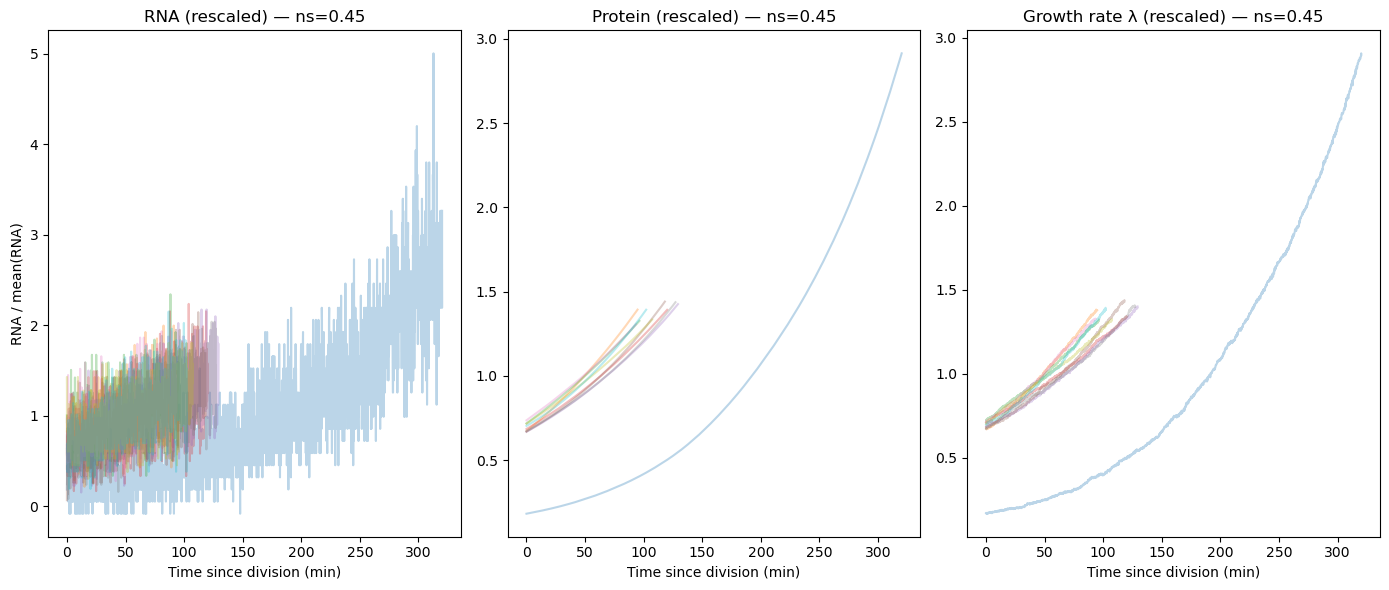

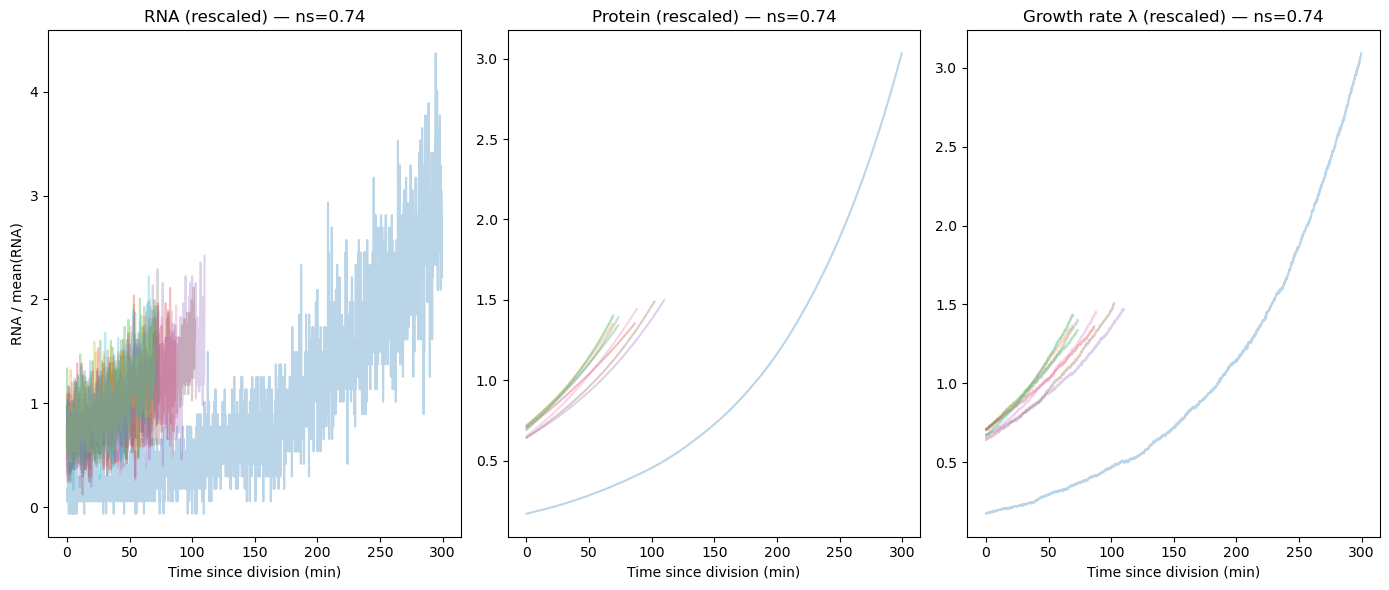

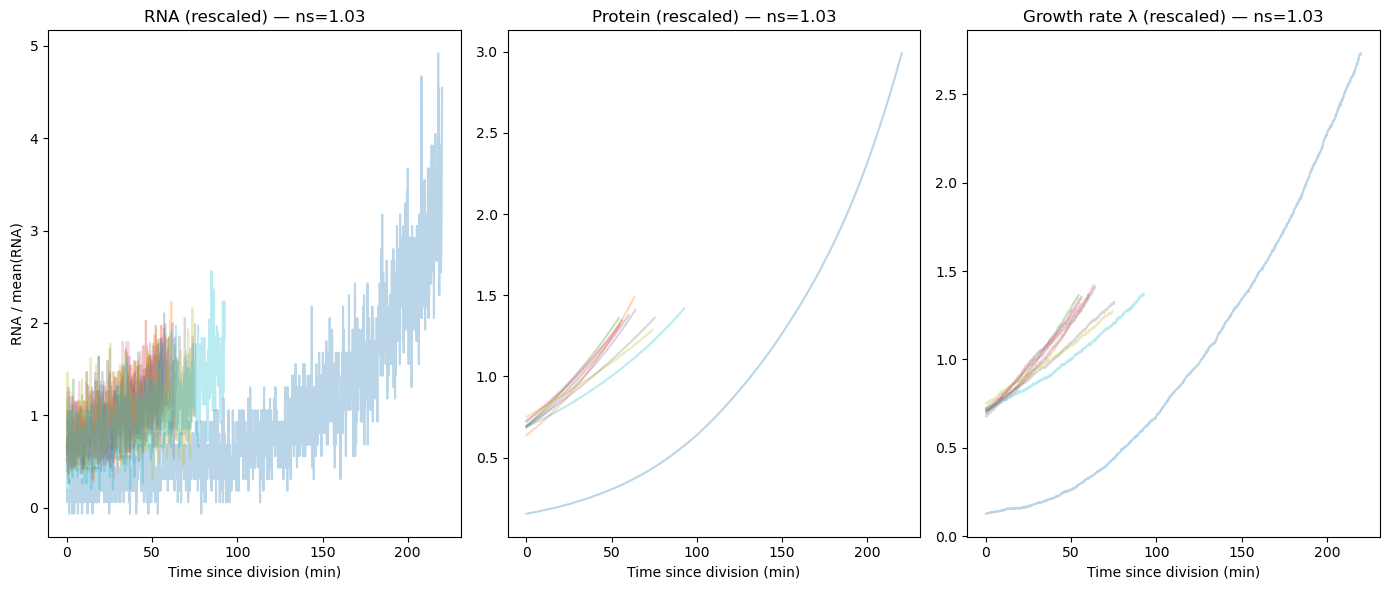

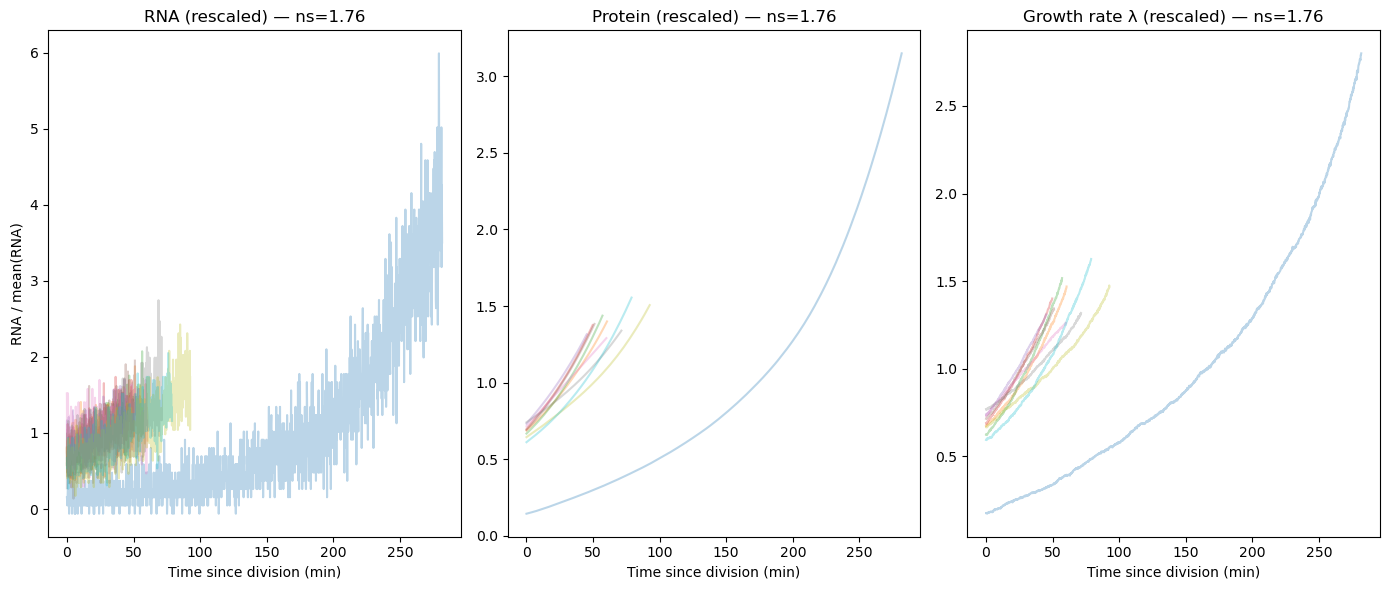

In [3]:
FILES = {0.45:"ns045.arrow", 0.74:"ns074.arrow", 1.03:"ns103.arrow", 1.76:"ns176.arrow"}

for ns, path in FILES.items():
    df = load_arrow(path)
    plot_within_cycle(df, ns)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def distribution_plots(df, ns, burn=5000, logscale=False):

    # -------------------------------------
    # Remove burn-in
    # -------------------------------------
    df2 = df[df["timestamp"] > burn]

    RNA = df2["mm(t)"] + df2["mt(t)"] + df2["mq(t)"] + df2["mr(t)"]
    PROT = df2["et(t)"] + df2["em(t)"] + df2["q(t)"]
    RATIO = RNA / PROT
    LAM = compute_lambda(df2)

    # -------------------------------------
    # Nice formatting defaults
    # -------------------------------------
    plt.figure(figsize=(14,10))
    sns.set_style("whitegrid")

    # ---- RNA ----
    ax1 = plt.subplot(2,2,1)
    sns.histplot(RNA, kde=True, ax=ax1)
    ax1.set_title(f"RNA distribution  (ns={ns})", fontsize=14)
    ax1.set_xlabel("RNA count (a.u.)", fontsize=12)
    ax1.set_ylabel("Density", fontsize=12)
    ax1.tick_params(axis='both', labelsize=10)
    if logscale: ax1.set_xscale("log")

    # ---- Protein ----
    ax2 = plt.subplot(2,2,2)
    sns.histplot(PROT, kde=True, ax=ax2)
    ax2.set_title(f"Protein distribution  (ns={ns})", fontsize=14)
    ax2.set_xlabel("Protein count (a.u.)", fontsize=12)
    ax2.set_ylabel("Density", fontsize=12)
    ax2.tick_params(axis='both', labelsize=10)
    if logscale: ax2.set_xscale("log")

    # ---- Ratio ----
    ax3 = plt.subplot(2,2,3)
    sns.histplot(RATIO, kde=True, ax=ax3)
    ax3.set_title(f"RNA/Protein ratio  (ns={ns})", fontsize=14)
    ax3.set_xlabel("RNA / Protein", fontsize=12)
    ax3.set_ylabel("Density", fontsize=12)
    ax3.tick_params(axis='both', labelsize=10)

    # ---- Growth rate λ ----
    ax4 = plt.subplot(2,2,4)
    sns.histplot(LAM, kde=True, ax=ax4)
    ax4.set_title(f"Growth rate λ distribution  (ns={ns})", fontsize=14)
    ax4.set_xlabel("λ  (1/min)", fontsize=12)
    ax4.set_ylabel("Density", fontsize=12)
    ax4.tick_params(axis='both', labelsize=10)
    if logscale: ax4.set_xscale("log")

    plt.tight_layout()
    plt.show()


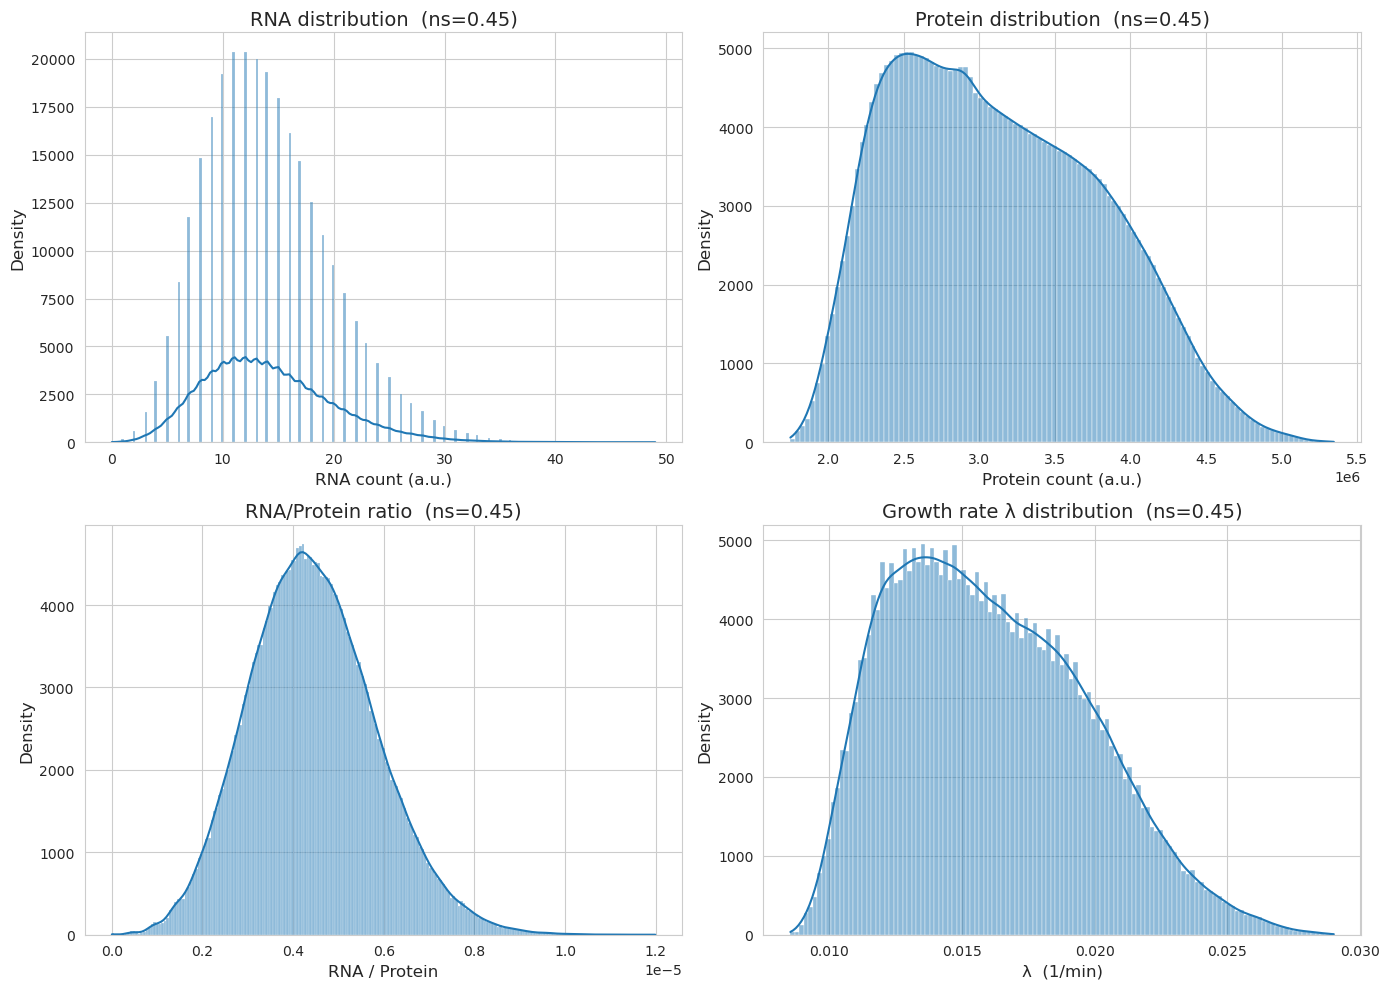

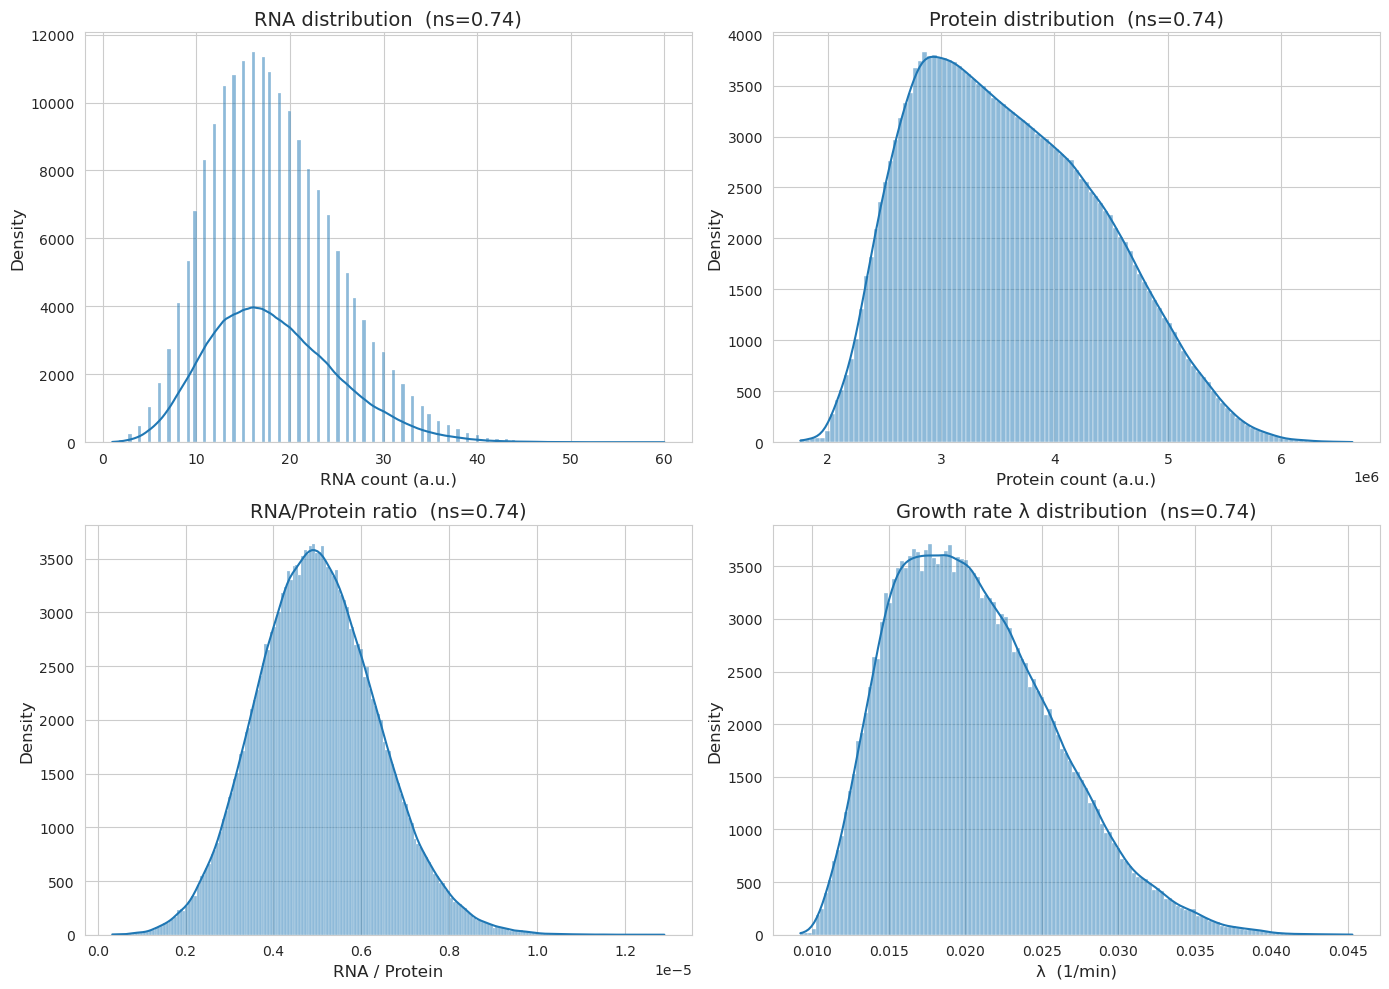

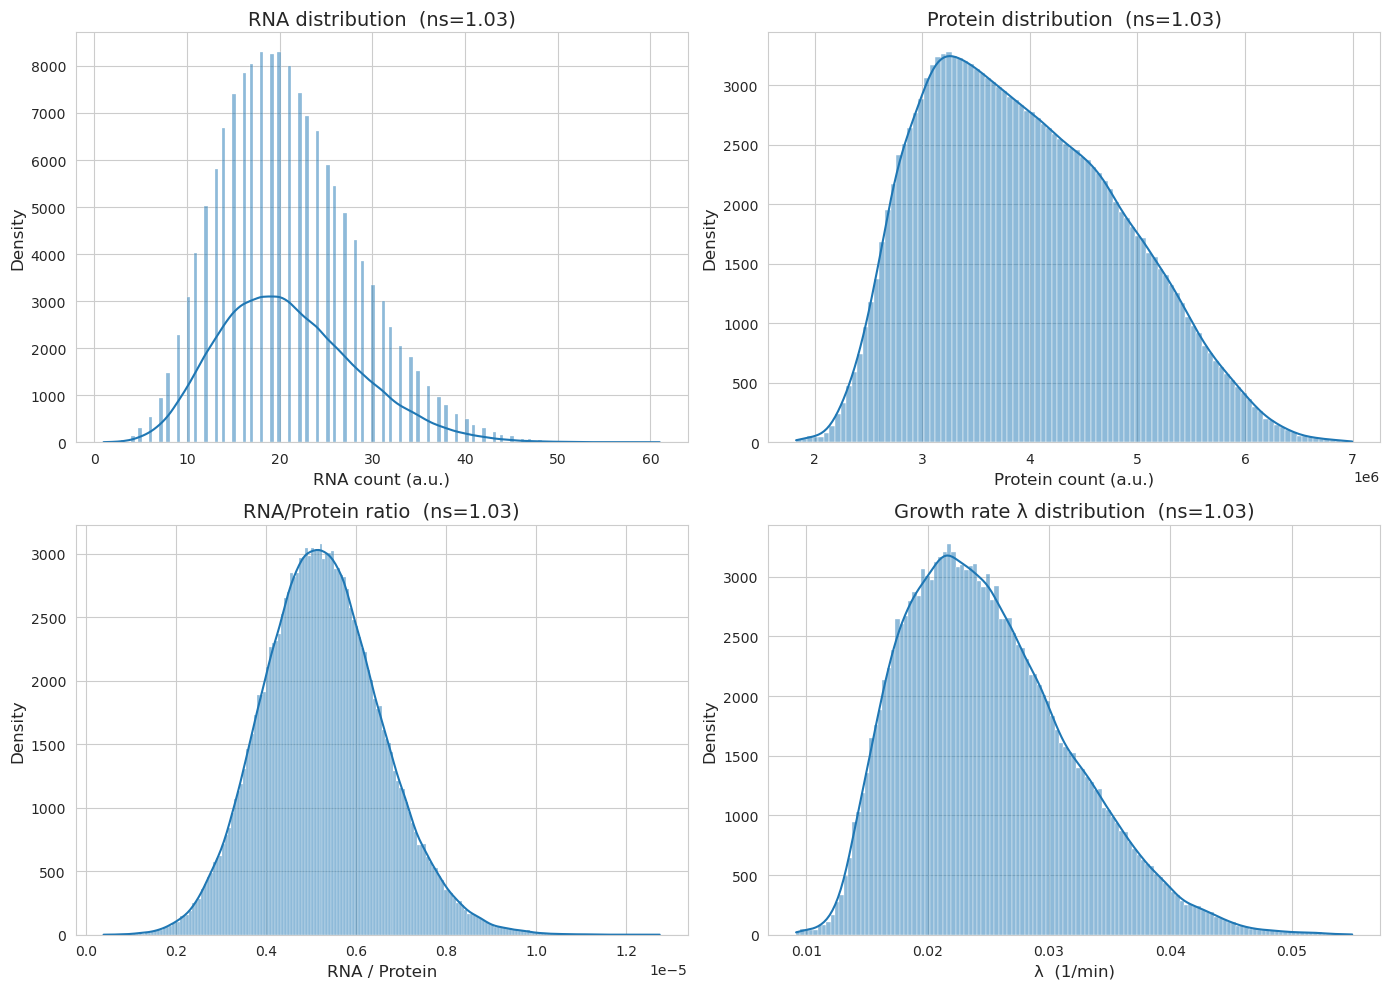

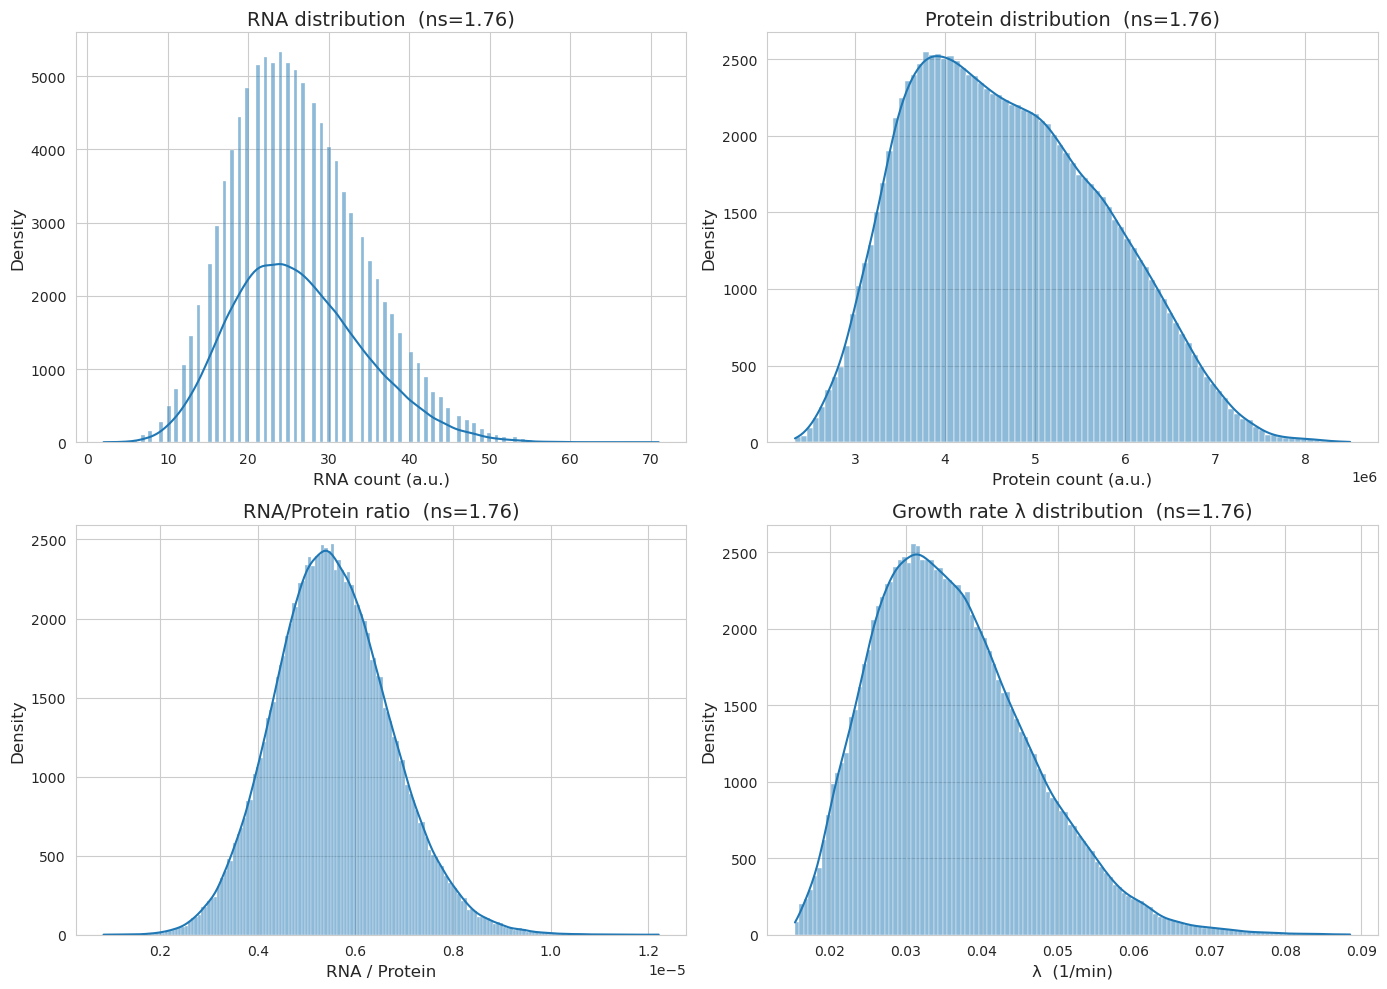

In [7]:
for ns, path in FILES.items():
    df = load_arrow(path)
    distribution_plots(df, ns)


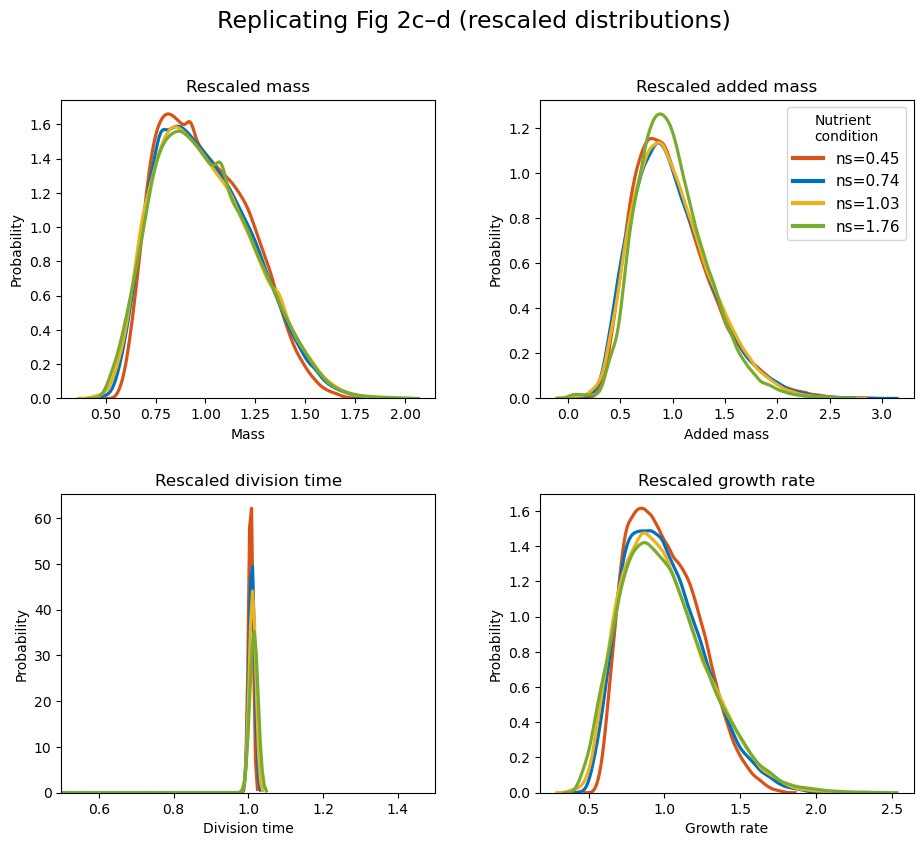

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.ipc as ipc

# -----------------------
# Read Arrow file
# -----------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as f:
        return ipc.open_file(f).read_all().to_pandas()

# -----------------------
# Compute mass(t)
# -----------------------
NR = 7549
NX = 300
def compute_mass(df):
    ribo = df["r(t)"] + df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    return NR * ribo + NX * (df["q(t)"] + df["et(t)"] + df["em(t)"])

# -----------------------
# Compute λ(t)
# -----------------------
def compute_lambda(df):
    a = df["a(t)"].values
    gmax = 1260.0
    Kgamma = 7.0
    gamma = gmax * a / (Kgamma + a)
    active = df["rmr(t)"] + df["rmt(t)"] + df["rmm(t)"] + df["rmq(t)"]
    ttrate = active * gamma
    return ttrate / 1e8

# -----------------------
# ns → file
# -----------------------
FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow"
}

colors = ["#D95319", "#0072BD", "#EDB120", "#77AC30"]
ns_values = list(FILES.keys())

mass_curves, added_mass_curves = {}, {}
divtime_curves, lambda_curves = {}, {}

# -----------------------
# Extract curves
# -----------------------
for ns, file in FILES.items():
    df = load_arrow(file)
    df = df[df["timestamp"] > 5000]   # burn-in

    mass = compute_mass(df)
    mass_curves[ns] = mass / np.mean(mass)

    dmass = np.diff(mass)
    added = dmass[dmass > 0]
    added_mass_curves[ns] = added / np.mean(added)

    t = df["timestamp"].values
    dt = np.diff(t)
    divtime_curves[ns] = dt / np.mean(dt)

    lam = compute_lambda(df)
    lambda_curves[ns] = lam / np.mean(lam)

# -----------------------
# PLOT with legend inside
# -----------------------
fig, axs = plt.subplots(2, 2, figsize=(11, 9))
plt.subplots_adjust(wspace=0.28, hspace=0.32)

paper_style = dict(linewidth=2.3)

# Panel c: rescaled mass
ax = axs[0,0]
for ns, col in zip(ns_values, colors):
    sns.kdeplot(mass_curves[ns], ax=ax, color=col, **paper_style)
ax.set_title("Rescaled mass")
ax.set_xlabel("Mass")
ax.set_ylabel("Probability")

# Panel c: rescaled added mass
ax = axs[0,1]
for ns, col in zip(ns_values, colors):
    sns.kdeplot(added_mass_curves[ns], ax=ax, color=col, **paper_style)
ax.set_title("Rescaled added mass")
ax.set_xlabel("Added mass")
ax.set_ylabel("Probability")

# ---- Legend INSIDE TOP-RIGHT PANEL ----
legend_labels = [f"ns={ns}" for ns in ns_values]
handles = [plt.Line2D([], [], color=col, linewidth=3) for col in colors]
axs[0,1].legend(handles, legend_labels,
                loc="upper right",
                frameon=True,
                fontsize=11,
                title="Nutrient\ncondition")

# Panel d: rescaled division time
ax = axs[1,0]
for ns, col in zip(ns_values, colors):
    sns.kdeplot(divtime_curves[ns], ax=ax, color=col, **paper_style)
ax.set_title("Rescaled division time")
ax.set_xlabel("Division time")
ax.set_ylabel("Probability")
ax.set_xlim(0.5, 1.5)

# Panel d: rescaled growth rate
ax = axs[1,1]
for ns, col in zip(ns_values, colors):
    sns.kdeplot(lambda_curves[ns], ax=ax, color=col, **paper_style)
ax.set_title("Rescaled growth rate")
ax.set_xlabel("Growth rate")
ax.set_ylabel("Probability")
plt.suptitle("Replicating Fig 2c–d (rescaled distributions)", fontsize=17)
plt.show()
